# 02 — 统计基础
## Phase 1：用统计检验判断市场信号是否真实

双均线策略在平安银行上表现如何？但我们怎么知道这个结果是**真实的规律**，还是只是**随机噪声**？

这个 notebook 教你用统计工具回答这个问题：

| 问题 | 工具 |
|------|------|
| 策略收益是否显著不为零？ | t 检验 |
| 股票之间有什么关联？ | 相关性分析 |
| 收益率是正态分布吗？ | 偏度/峰度/Shapiro检验 |
| 截面收益有没有规律？ | 排名相关性（Spearman IC）|

**先决条件**：跑过 `00_data_prep.ipynb`，`data/processed/` 下有缓存数据

In [1]:
import sys
sys.path.insert(0, "../../..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from utils.data_loader import calc_returns, build_return_matrix
from utils.local_data_loader import load_local_stock, load_price_wide, get_all_symbols
from utils.metrics import performance_summary

print("✅ 导入成功")

✅ 导入成功


In [2]:
# 加载单股数据（用于前几节）
SYMBOL = "000001"   # 平安银行
START  = "2019-01-01"
END    = "2024-12-31"

df = load_local_stock(SYMBOL)   # 从本地 CSV 加载
df = df.loc[START:END]
ret = calc_returns(df["close"])

print(f"日收益率: {len(ret)} 个交易日")
print(ret.describe().round(4))

日收益率: 1455 个交易日
count    1455.0000
mean        0.0004
std         0.0200
min        -0.0997
25%        -0.0107
50%        -0.0010
75%         0.0098
max         0.1004
Name: close, dtype: float64


## 1. 收益率分布 — 它是正态的吗？

金融教科书假设收益率是正态分布，但现实中它有**胖尾**（极端事件比正态预测的更常见）。

理解这一点，才能知道夏普比率等指标的局限性。

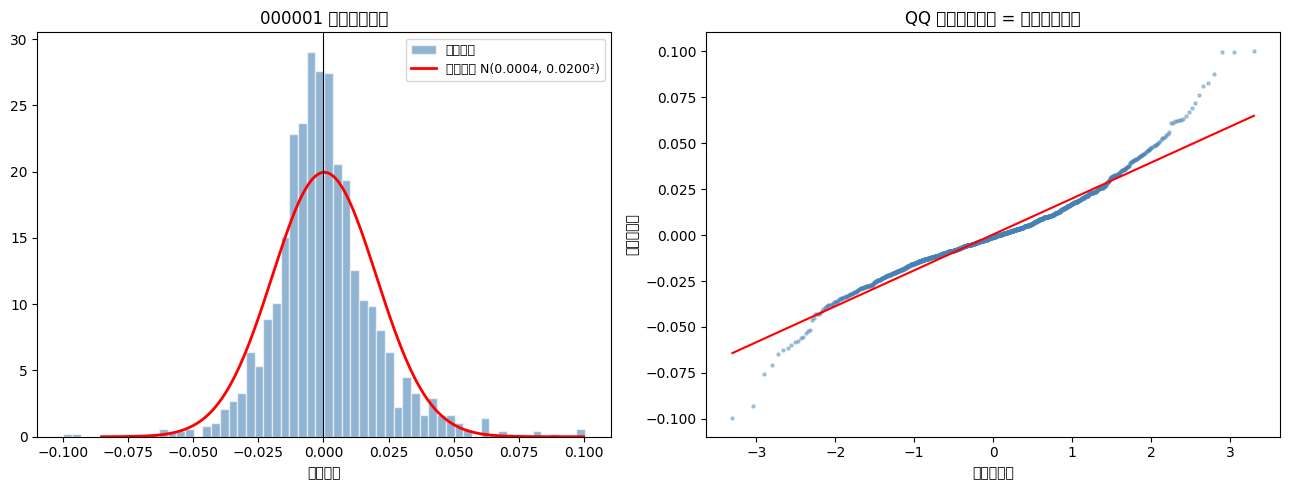

偏度 (Skewness): 0.5165  （正态=0，负值=左偏/有大跌）
超额峰度 (Kurtosis): 3.2563  （正态=0，正值=胖尾）

Shapiro-Wilk 检验: stat=0.9446, p=0.000000
结论: ❌ 拒绝正态分布 (p < 0.05)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左图：直方图 + 理论正态曲线
ax = axes[0]
ax.hist(ret, bins=60, density=True, alpha=0.6, color="steelblue", edgecolor="white", label="实际分布")

mu, sigma = ret.mean(), ret.std()
x = np.linspace(ret.quantile(0.001), ret.quantile(0.999), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color="red", linewidth=2, label=f"理论正态 N({mu:.4f}, {sigma:.4f}²)")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"{SYMBOL} 日收益率分布")
ax.set_xlabel("日收益率")
ax.legend(fontsize=9)

# 右图：QQ 图（偏离直线 = 非正态）
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(ret, dist="norm")
ax2.scatter(osm, osr, s=5, alpha=0.4, color="steelblue")
ax2.plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=1.5)
ax2.set_title("QQ 图（偏离红线 = 分布有胖尾）")
ax2.set_xlabel("理论分位数")
ax2.set_ylabel("样本分位数")

plt.tight_layout()
plt.show()

# 统计量
skew = ret.skew()
kurt = ret.kurt()  # 超额峰度（正态 = 0）

print(f"偏度 (Skewness): {skew:.4f}  （正态=0，负值=左偏/有大跌）")
print(f"超额峰度 (Kurtosis): {kurt:.4f}  （正态=0，正值=胖尾）")

# Shapiro-Wilk 正态性检验（样本量大时用 K-S 检验）
sample = ret.sample(500, random_state=42)  # Shapiro 要求 < 5000
stat_sw, p_sw = stats.shapiro(sample)
print(f"\nShapiro-Wilk 检验: stat={stat_sw:.4f}, p={p_sw:.6f}")
print(f"结论: {'❌ 拒绝正态分布 (p < 0.05)' if p_sw < 0.05 else '✅ 不能拒绝正态分布'}")

## 2. t 检验 — 策略收益显著不为零吗？

零假设 H₀：策略的日均收益率 = 0（即没有 alpha）  
备择假设 H₁：日均收益率 ≠ 0

p < 0.05 → 拒绝 H₀ → 收益在统计上显著  
p ≥ 0.05 → 不能拒绝 H₀ → 可能只是运气

In [4]:
from strategies.examples.dual_ma import DualMACrossStrategy
from strategies.base import StrategyConfig

config = StrategyConfig(
    name="双均线_20_60",
    params={"fast_period": 20, "slow_period": 60},
    commission=0.0002,
    slippage=0.0002,
)
strategy = DualMACrossStrategy(config)
results = strategy.run(df)
strat_ret = results["returns"].dropna()

def t_test_returns(returns: pd.Series, name: str = "策略"):
    """单样本 t 检验：日均收益是否显著不为零"""
    t_stat, p_value = stats.ttest_1samp(returns, popmean=0)
    n = len(returns)
    mean_daily = returns.mean()
    mean_annual = mean_daily * 252
    se = returns.std() / np.sqrt(n)
    ci_lower = mean_daily - 1.96 * se
    ci_upper = mean_daily + 1.96 * se
    
    print(f"【{name}】单样本 t 检验")
    print(f"  样本量      : {n} 个交易日")
    print(f"  日均收益率  : {mean_daily:.4%}  （年化: {mean_annual:.2%}）")
    print(f"  95% 置信区间: [{ci_lower:.4%}, {ci_upper:.4%}]")
    print(f"  t 统计量    : {t_stat:.4f}")
    print(f"  p 值        : {p_value:.4f}")
    sig = "✅ 显著 (p<0.05)" if p_value < 0.05 else "❌ 不显著 (p≥0.05)"
    print(f"  结论        : {sig}")
    print()

t_test_returns(strat_ret, "双均线策略")
t_test_returns(ret, "买入持有")

【双均线策略】单样本 t 检验
  样本量      : 1455 个交易日
  日均收益率  : 0.0008%  （年化: 0.19%）
  95% 置信区间: [-0.0711%, 0.0726%]
  t 统计量    : 0.0208
  p 值        : 0.9834
  结论        : ❌ 不显著 (p≥0.05)

【买入持有】单样本 t 检验
  样本量      : 1455 个交易日
  日均收益率  : 0.0365%  （年化: 9.19%）
  95% 置信区间: [-0.0663%, 0.1392%]
  t 统计量    : 0.6954
  p 值        : 0.4869
  结论        : ❌ 不显著 (p≥0.05)



### 2.1 双样本 t 检验 — 策略 vs 买入持有，谁更好？

比较两个策略的收益分布是否有显著差异。

In [5]:
# 对齐日期
common_idx = strat_ret.index.intersection(ret.index)
s1 = strat_ret.loc[common_idx]
s2 = ret.loc[common_idx]

# 独立样本 t 检验
t2, p2 = stats.ttest_ind(s1, s2)

print(f"双样本 t 检验（策略 vs 买入持有）")
print(f"  策略均值    : {s1.mean():.4%} / 日")
print(f"  买入持有均值: {s2.mean():.4%} / 日")
print(f"  差值        : {s1.mean() - s2.mean():.4%} / 日")
print(f"  t 统计量    : {t2:.4f}")
print(f"  p 值        : {p2:.4f}")
print(f"  结论: {'✅ 两者有显著差异' if p2 < 0.05 else '❌ 两者无显著差异（策略没有跑赢）'}")

双样本 t 检验（策略 vs 买入持有）
  策略均值    : 0.0008% / 日
  买入持有均值: 0.0365% / 日
  差值        : -0.0357% / 日
  t 统计量    : -0.5578
  p 值        : 0.5770
  结论: ❌ 两者无显著差异（策略没有跑赢）


## 3. 相关性分析

### 3.1 股票之间的相关性

A 股个股之间的相关性通常较高（因为同向受政策/情绪驱动）。
这意味着持有多只股票未必能充分分散风险。

In [6]:
# 选几只有代表性的股票做相关性分析
SAMPLE_STOCKS = {
    "000001": "平安银行",
    "000002": "万科A",
    "600519": "贵州茅台",
    "000858": "五粮液",
    "300750": "宁德时代",
    "601318": "中国平安",
    "000333": "美的集团",
    "002594": "比亚迪",
}

# ── 用本地数据替代逐只下载 ──
_syms = list(SAMPLE_STOCKS.keys())
_price = load_price_wide(_syms, START, END)
_ret_wide = _price.pct_change()
rets_dict = {SAMPLE_STOCKS[s]: _ret_wide[s].dropna() for s in _syms if s in _ret_wide.columns}

ret_df = pd.DataFrame(rets_dict).dropna()
print(f"数据形状: {ret_df.shape}")
ret_df.head(3)

数据形状: (1455, 8)


,平安银行,万科A,贵州茅台,五粮液,宁德时代,中国平安,美的集团,比亚迪
date,,,,,,,,
2019-01-03,0.009793,0.007113,-0.014992,-0.019624,0.002308,0.009061,-0.006586,-0.022575
2019-01-04,0.050647,0.035729,0.020339,0.011846,0.042395,0.016343,0.021823,0.053891
2019-01-07,-0.001026,0.004813,0.005797,-0.004643,0.005977,-0.005125,0.000000,0.014610


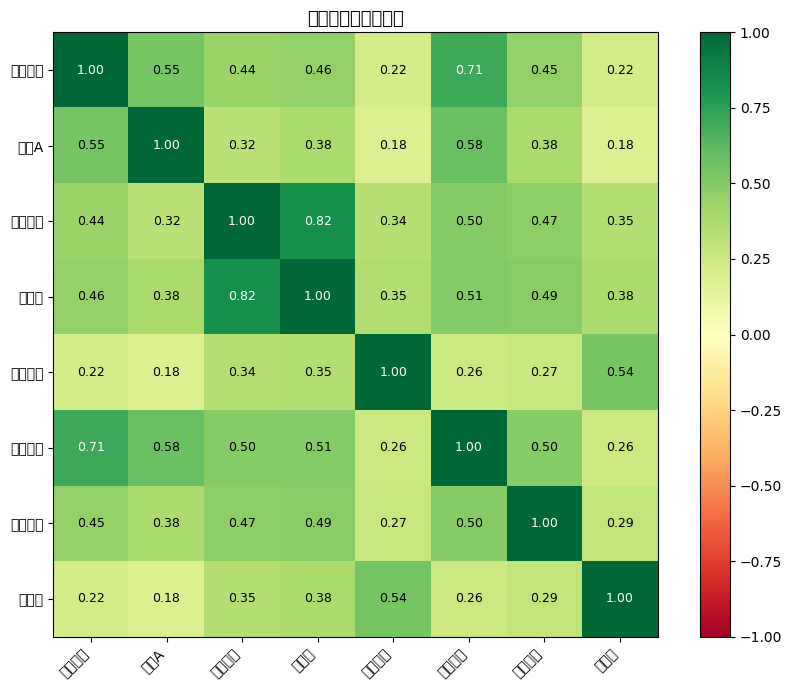


股票对相关系数 — 均值: 0.406  中位数: 0.380  最大: 0.820


In [7]:
import matplotlib.colors as mcolors

corr = ret_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
cmap = plt.cm.RdYlGn
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ticks = range(len(corr))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(corr.columns, fontsize=10)

for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)

ax.set_title("日收益率相关性矩阵", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 提取非对角线相关系数
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
off_diag = corr.values[mask]
print(f"\n股票对相关系数 — 均值: {off_diag.mean():.3f}  中位数: {np.median(off_diag):.3f}  最大: {off_diag.max():.3f}")

### 3.2 滚动相关性 — 相关性会变化吗？

市场动荡时期（如 2020 年疫情、2022 年调整），个股之间相关性会急剧上升。
这正是投资组合在最需要分散时反而失效的原因。

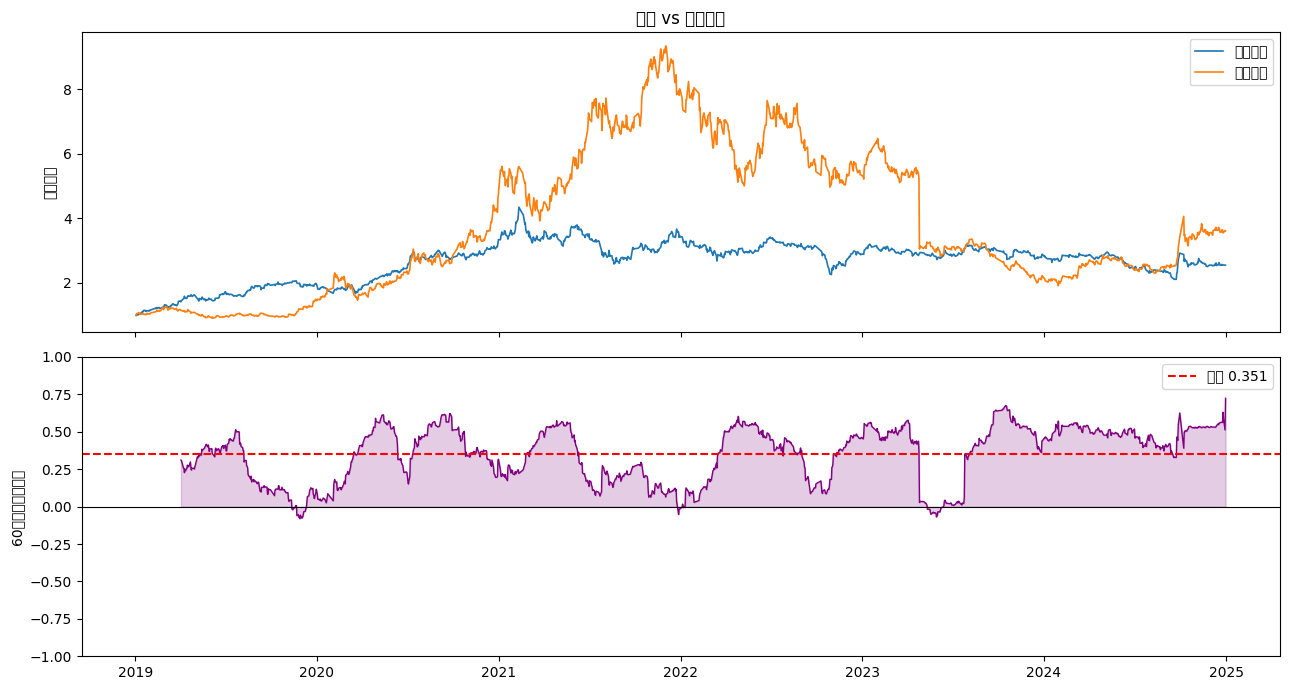

In [8]:
# 茅台 vs 宁德时代的滚动60日相关性
if "贵州茅台" in ret_df.columns and "宁德时代" in ret_df.columns:
    r1 = ret_df["贵州茅台"]
    r2 = ret_df["宁德时代"]
    rolling_corr = r1.rolling(60).corr(r2)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    
    ax1.plot(r1.index, (1 + r1).cumprod(), label="贵州茅台", linewidth=1.2)
    ax1.plot(r2.index, (1 + r2).cumprod(), label="宁德时代", linewidth=1.2)
    ax1.set_ylabel("累计净值")
    ax1.legend()
    ax1.set_title("茅台 vs 宁德时代")
    
    ax2.plot(rolling_corr.index, rolling_corr, color="purple", linewidth=1)
    ax2.fill_between(rolling_corr.index, rolling_corr, alpha=0.2, color="purple")
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.axhline(rolling_corr.mean(), color="red", linestyle="--", label=f"均值 {rolling_corr.mean():.3f}")
    ax2.set_ylabel("60日滚动相关系数")
    ax2.set_ylim(-1, 1)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

## 4. 截面 IC — 因子排名与收益排名的关联

**IC（信息系数）**是因子研究的核心指标：
- 用当日因子值的排名，预测**下一期**收益率的排名
- IC > 0 说明因子有正向预测能力
- |IC| > 0.03 一般认为有效，|ICIR| > 0.5 认为稳定

这里用**动量因子**（过去20日收益率）做示例。

> 先决条件：`00_data_prep.ipynb` 已运行，有价格宽表缓存

In [9]:
# 加载价格宽表
try:
    symbols = get_all_symbols()[:500]  # 取前500只，速度更快
    price_wide = load_price_wide(symbols, START, END)
    ret_wide = build_return_matrix(price_wide)
    HAS_WIDE_DATA = True
    print(f"✅ 价格宽表加载成功: {price_wide.shape}")
except Exception as e:
    HAS_WIDE_DATA = False
    print(f"⚠ 宽表数据不可用: {e}")
    print("请先运行 00_data_prep.ipynb")

✅ 价格宽表加载成功: (1456, 500)


【动量_20日】IC 统计摘要
  IC 均值    : -0.0352
  IC 标准差  : 0.1757
  ICIR       : -0.2006
  IC>0 占比  : 41.74%
  t 统计量   : -7.5987  (|t|>2 视为显著)



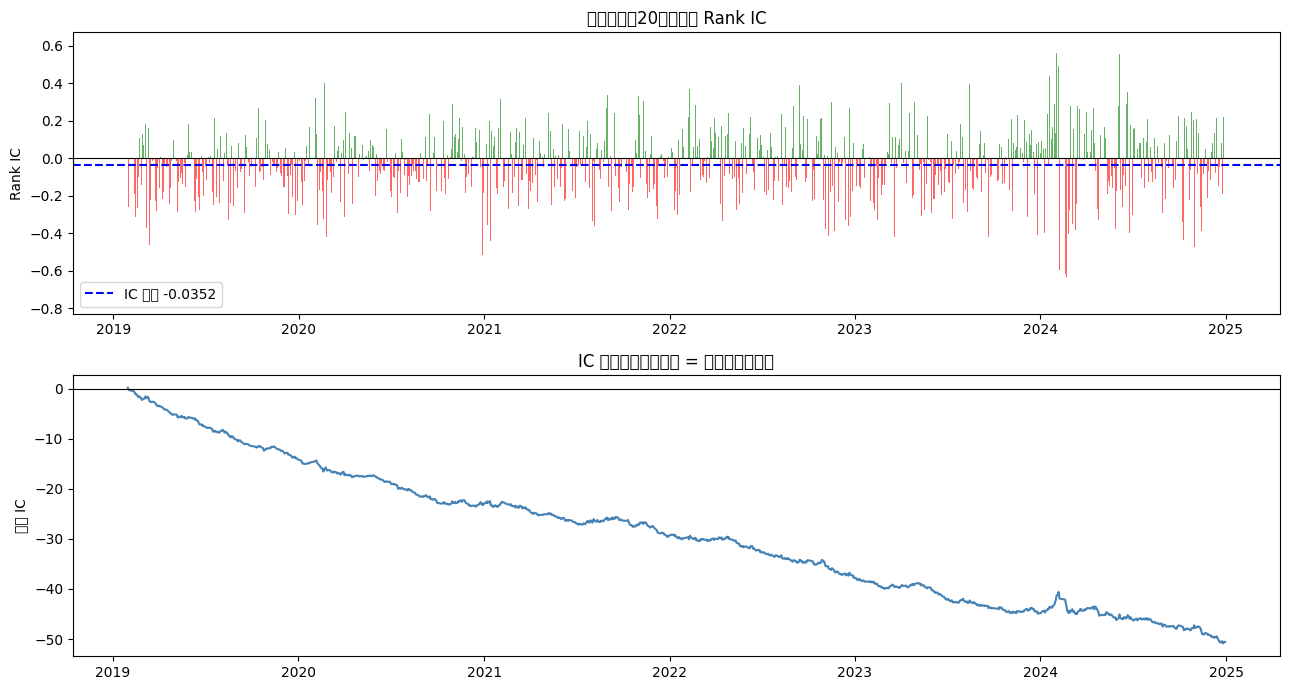

In [10]:
if HAS_WIDE_DATA:
    from utils.factor_analysis import compute_ic_series, ic_summary
    
    # 构建动量因子（过去20日收益率）
    momentum_20 = price_wide.pct_change(20)   # 20日价格变化率，即动量
    
    # 下一日收益率（IC 计算用）
    next_ret = ret_wide.shift(-1)   # 向前移一天 = 预测明天的收益
    
    # 计算 IC 序列（Rank IC = Spearman）
    ic_series = compute_ic_series(momentum_20, next_ret, method="spearman")
    
    ic_stats = ic_summary(ic_series, name="动量_20日")
    
    # 画 IC 时序
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))
    
    ax1.bar(ic_series.index, ic_series, color=ic_series.apply(lambda x: "green" if x > 0 else "red"),
            alpha=0.6, width=1)
    ax1.axhline(0, color="black", linewidth=0.8)
    ax1.axhline(ic_series.mean(), color="blue", linestyle="--", linewidth=1.5,
                label=f"IC 均值 {ic_series.mean():.4f}")
    ax1.set_title("动量因子（20日）日频 Rank IC")
    ax1.set_ylabel("Rank IC")
    ax1.legend()
    
    # 累积 IC
    ax2.plot(ic_series.index, ic_series.cumsum(), color="steelblue", linewidth=1.5)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_title("IC 累积和（上升趋势 = 因子持续有效）")
    ax2.set_ylabel("累积 IC")
    
    plt.tight_layout()
    plt.show()
else:
    print("跳过（需要宽表数据）")

## 5. 滚动统计 — 均值回归 vs 趋势

股价是**趋势**的还是**均值回归**的？
- 趋势（动量）：过去涨，未来继续涨 → autocorrelation > 0
- 均值回归：过去涨太多，未来会跌 → autocorrelation < 0

不同的时间尺度下，答案可能完全不同。

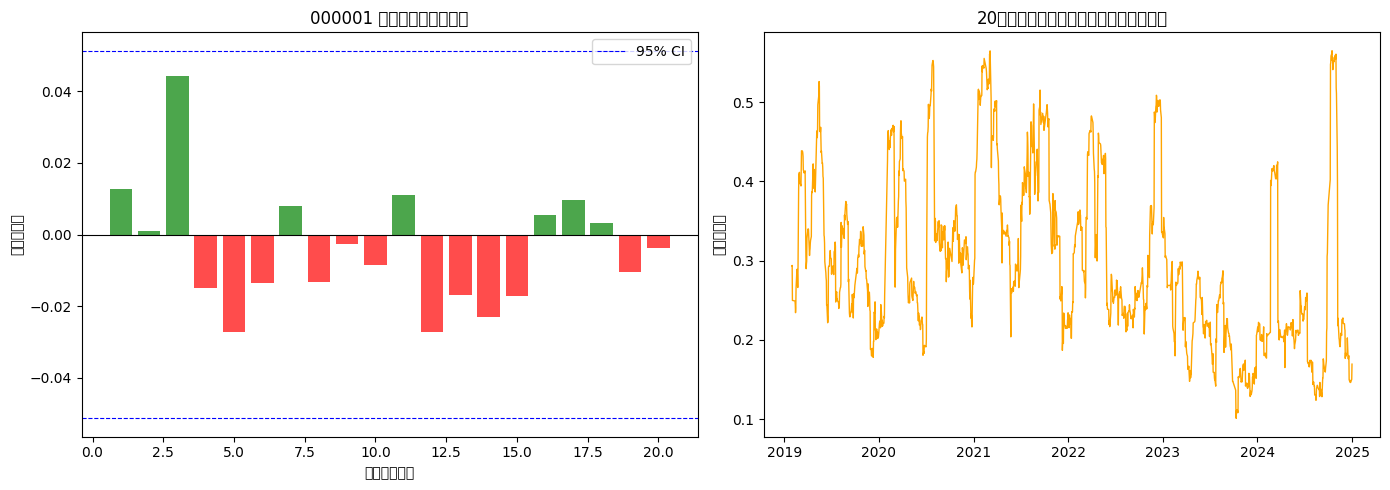


Ljung-Box 自相关检验:
     lb_stat  lb_pvalue
5   4.491923   0.480965
10  5.224823   0.875662
20  8.480032   0.988185

p < 0.05 → 收益率存在显著自相关（非随机游走）


In [11]:
# 日收益率的自相关系数（不同滞后期）
lags = range(1, 21)
autocorrs = [ret.autocorr(lag=lag) for lag in lags]

# 用 Ljung-Box 检验整体自相关是否显著
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_result = acorr_ljungbox(ret, lags=[5, 10, 20], return_df=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 自相关图
ax = axes[0]
colors = ["green" if c > 0 else "red" for c in autocorrs]
ax.bar(list(lags), autocorrs, color=colors, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
# 95% 置信区间
ci = 1.96 / np.sqrt(len(ret))
ax.axhline(ci, color="blue", linestyle="--", linewidth=0.8, label="95% CI")
ax.axhline(-ci, color="blue", linestyle="--", linewidth=0.8)
ax.set_title(f"{SYMBOL} 日收益率自相关系数")
ax.set_xlabel("滞后期（天）")
ax.set_ylabel("自相关系数")
ax.legend()

# 滚动波动率（观察波动聚集效应）
ax2 = axes[1]
rolling_vol = ret.rolling(20).std() * np.sqrt(252)
ax2.plot(rolling_vol.index, rolling_vol, color="orange", linewidth=1)
ax2.set_title("20日滚动年化波动率（波动率聚集效应）")
ax2.set_ylabel("年化波动率")

plt.tight_layout()
plt.show()

print("\nLjung-Box 自相关检验:")
print(lb_result.to_string())
print("\np < 0.05 → 收益率存在显著自相关（非随机游走）")

In [12]:
# 不同时间尺度的动量 vs 反转
horizons = {
    "1日":   1,
    "5日":   5,
    "20日": 20,
    "60日": 60,
    "120日": 120,
    "250日": 250,
}

print("不同持有期收益率 vs 未来1日收益率的相关性")
print(f"{'持有期':<10} {'相关系数':>10} {'解读':>20}")
print("-" * 45)
for name, lag in horizons.items():
    past_ret = df["close"].pct_change(lag)
    future_ret = df["close"].pct_change(1).shift(-1)
    corr = past_ret.corr(future_ret)
    meaning = "动量↑" if corr > 0.02 else ("反转↓" if corr < -0.02 else "无显著规律")
    print(f"{name:<10} {corr:>10.4f} {meaning:>20}")

不同持有期收益率 vs 未来1日收益率的相关性
持有期              相关系数                   解读
---------------------------------------------
1日             0.0127                无显著规律
5日             0.0057                无显著规律
20日           -0.0245                  反转↓
60日           -0.0120                无显著规律
120日          -0.0041                无显著规律
250日          -0.0342                  反转↓


---

## Phase 1 统计基础完成 ✅

| 知识点 | 核心结论 |
|--------|----------|
| 收益率分布 | 不是正态分布——有胖尾，峰度 > 0，偏度为负 |
| t 检验 | 双均线策略收益可能不显著（p ≥ 0.05 时别骗自己） |
| 相关性 | A 股个股高度相关，分散化效果有限 |
| 截面 IC | 动量因子 IC 接近 0 说明短期动量在 A 股效果弱 |
| 自相关 | 日收益率基本无序列相关，波动率有聚集效应 |

### 关键教训

> **「看起来赚钱」≠「统计上显著赚钱」**  
> 在进入 Phase 2 因子研究之前，所有结论都要过 t 检验和 IC 检验这一关。

### 下一步

→ `03_single_stock_analysis.ipynb`：用上述工具系统分析任意一只股票  
→ Phase 2：`research/factors/` 下构建经典因子（动量、价值、质量）